In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import healpy as hp
import astropy.io.fits as fits
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as mcolors

In [3]:
# Input cleaned maps from initial cleaning fit
initial_70_map="INITIAL_Maps/Initial_Cleaned_70GHz.fits"
initial_70=hp.fitsfunc.read_map(initial_70_map,field=[0])

initial_94_map="INITIAL_Maps/Initial_Cleaned_94GHz.fits"
initial_94=hp.fitsfunc.read_map(initial_94_map,field=[0])

initial_100_map="INITIAL_Maps/Initial_Cleaned_100GHz.fits"
initial_100=hp.fitsfunc.read_map(initial_100_map,field=[0])

initial_143_map="INITIAL_Maps/Initial_Cleaned_143GHz.fits"
initial_143=hp.fitsfunc.read_map(initial_143_map,field=[0])

In [4]:
best_stack = np.vstack((initial_70, initial_94, initial_100, initial_143))
stdv_map = np.std(best_stack, axis=0)

In [5]:
# 1% mask (description in Section 3.5)
mask_1p="../ELC_Masks/ELC_1percent_mask.fits"
mask_1p=hp.fitsfunc.read_map(mask_1p,field=[0])

In [6]:
# Reverse 1% map so that pixels removed by mask are now 1s and pixels kept by mask are now 0s
reverse_1p = 1-mask_1p
reverse_1p = reverse_1p.astype(float)
reverse_1p[reverse_1p == 0] = np.nan

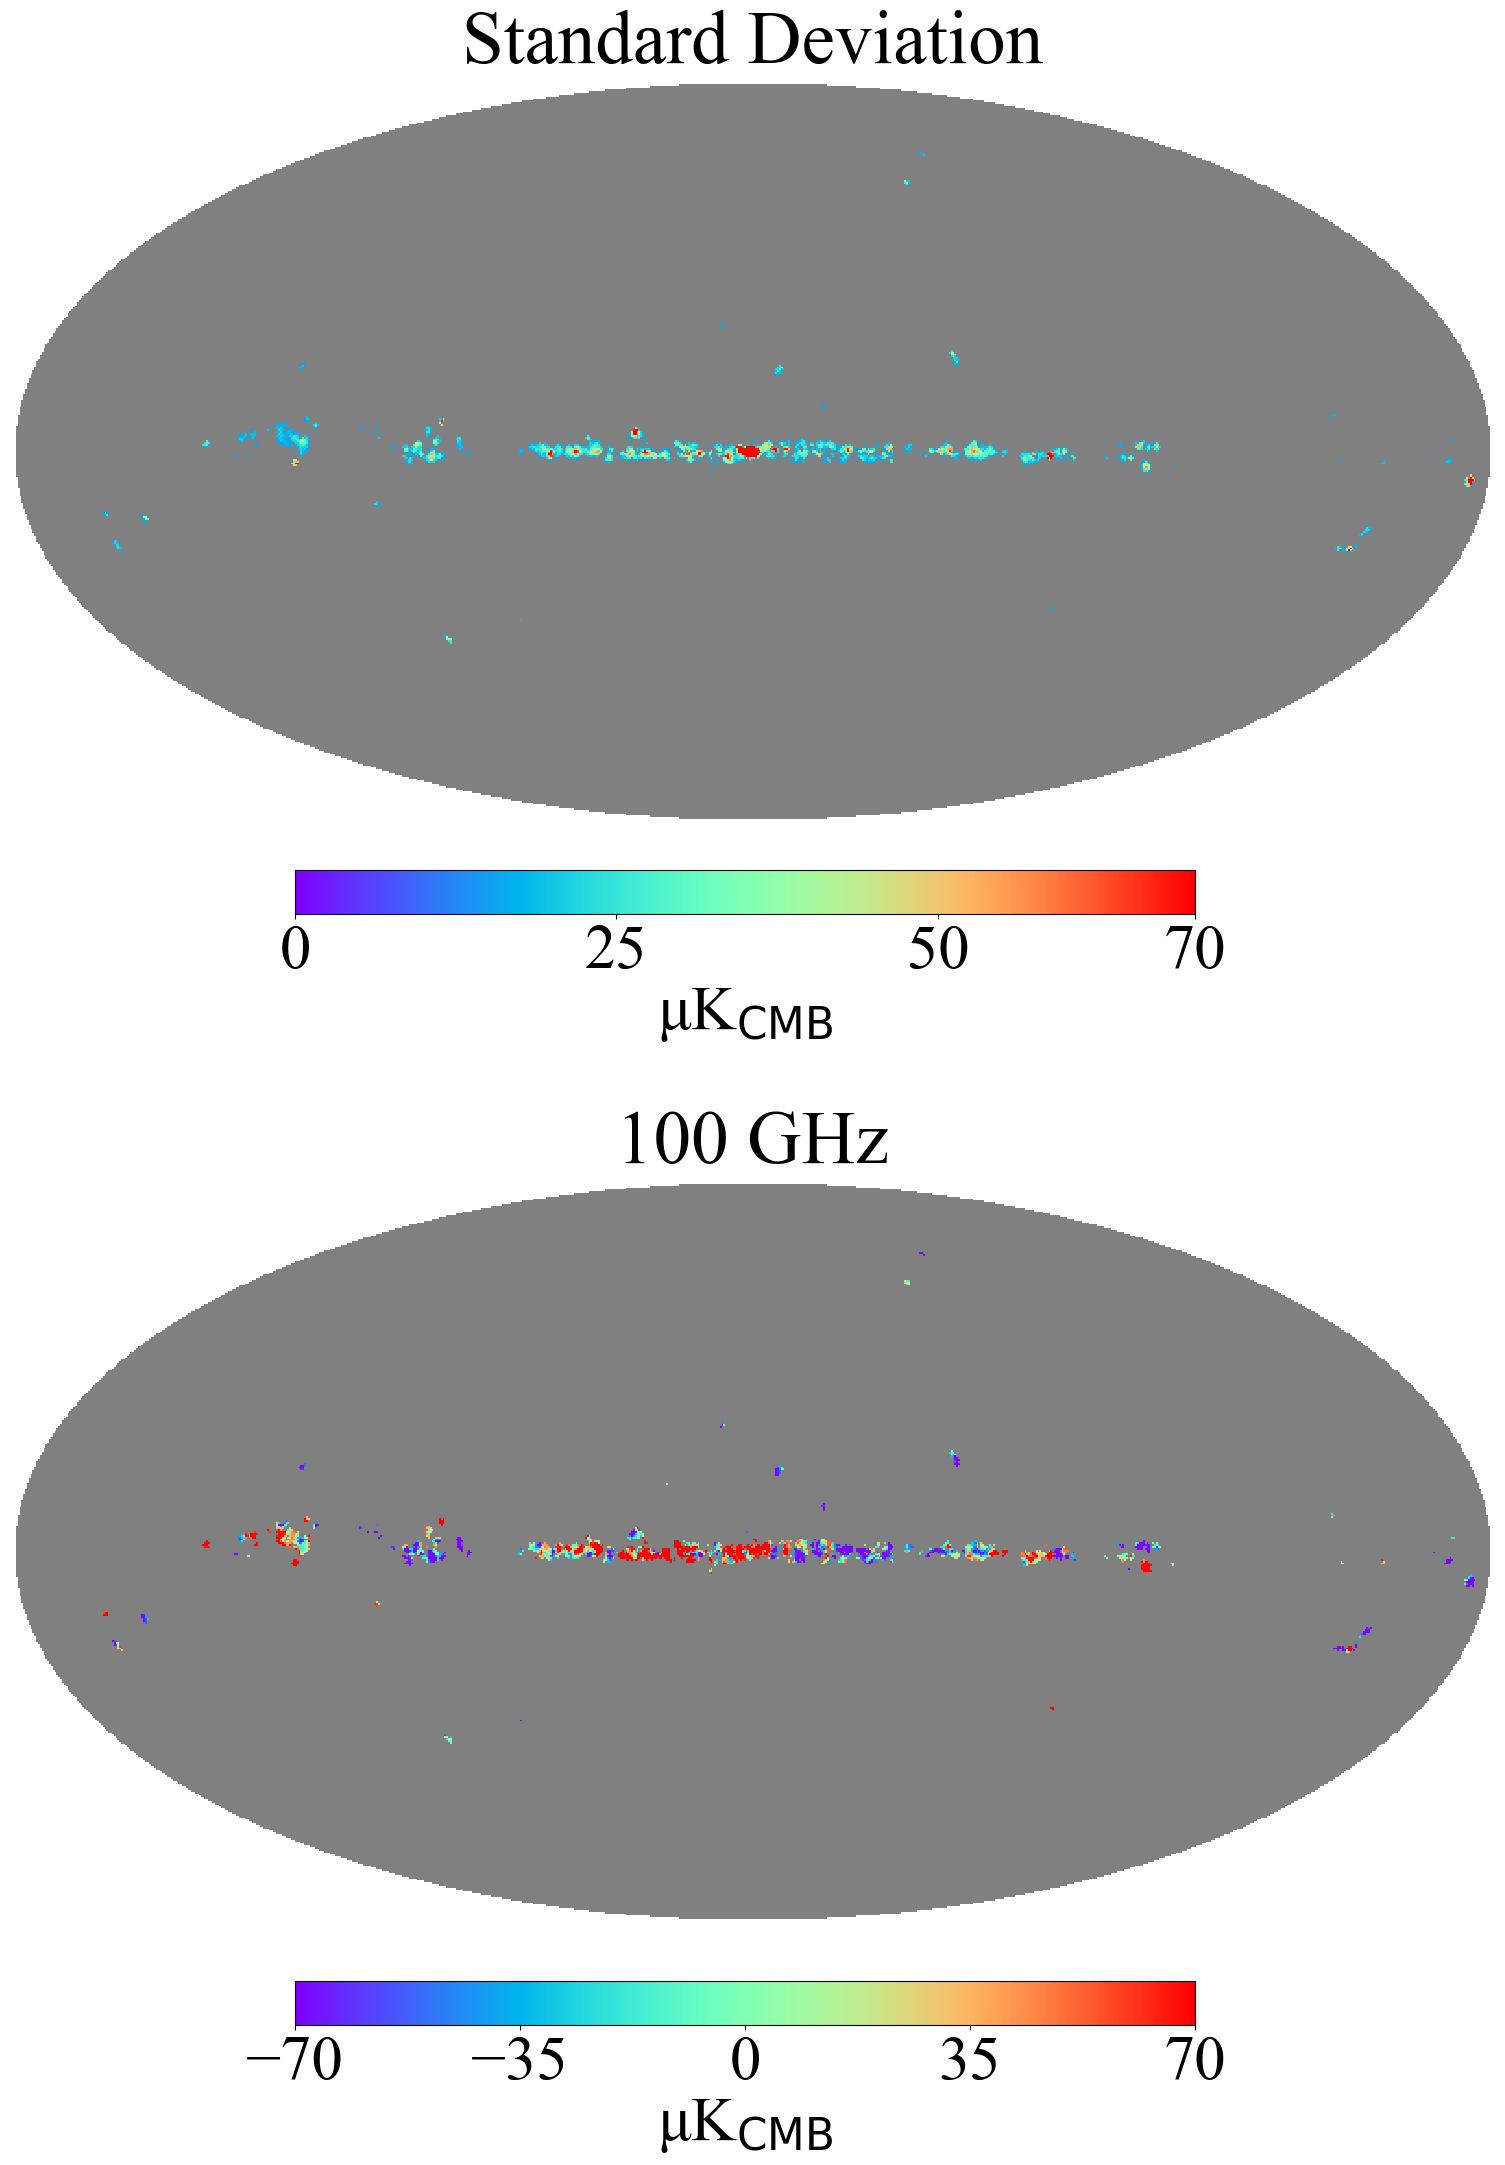

In [7]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 45})

figsize = (15, 22)
fig = plt.figure(figsize=figsize)

# Map of standard deviation of 4 best maps showing the pixels removed by the 1% mask
hp.mollview((stdv_map*reverse_1p)*1000, title = 'Standard Deviation', sub = 211, min = 0, max = 70, cbar = False, cmap = 'rainbow')
# Add a colorbar at the bottom of this map
cbar_ax = fig.add_axes([0.2, 0.53, 0.6, 0.02]) 
norm = mcolors.Normalize(vmin=0, vmax=70)
sm = cm.ScalarMappable(cmap='rainbow', norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# Colorbar is 1 sigma CMB rms
cbar.set_ticks([0, 25, 50, 70])
cbar.set_label(r'μK$_{\rm CMB}$')  

# Initial cleaning fit 100 GHz map showing the pixels removed by the 1% mask
hp.mollview((initial_100*reverse_1p)*1000, min = -70, max = 70, title = '100 GHz', cmap = 'rainbow', sub = 212,cbar=False)
# Add a colorbar at the bottom of this map
cbar_ax = fig.add_axes([0.2, 0.025, 0.6, 0.02])
# Colorbar is +/- 1 sigma CMB rms
norm = mcolors.Normalize(vmin=-70, vmax=70)
sm = cm.ScalarMappable(cmap='rainbow', norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([-70, -35, 0, 35, 70])
cbar.set_label(r'μK$_{\rm CMB}$') 